# All annotated verbs vs all verbs

In [1]:
import sqlite3
import pandas as pd
from tqdm import tqdm
import powerlaw as pwl
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np


In [12]:
con = sqlite3.connect("vp_data2_isikud.db")
cur = con.cursor()
cur.execute('ATTACH DATABASE "v33.db" AS v33')

## base tabel kus on verb, kääne, elus_cnt, koht_cnt, distinct root count  

In [3]:
query = """

SELECT distinct
base.verb as verb,
base.verb_compound as verb_compound,
base.kaane as kaane,
base.elus_cnt as elus_cnt,
base.koht_cnt as koht_cnt,
base.root_cnt as root_cnt,
cover.annotated as annotated

from 

transactions_verbs_obl_kohakaandes_eluskoht_root_counts_distinct_base_wcomps_v1 as base
left join
transactions_verbs_obl_kohakaandes_root_counts_distinct_coverage_v2_wcomps as cover
on base.verb=cover.verb
and base.verb_compound = cover.verb_compound
and base.root_cnt = cover.root_count
and base.kaane = cover.kaane
"""

source3 = pd.read_sql_query(query, con)
#source3

In [4]:
source3["elus_div"] = source3["elus_cnt"]/source3["root_cnt"]
source3["koht_div"] = source3["koht_cnt"]/source3["root_cnt"]

source3["kaane2"] = ''

source3.loc[source3['kaane'] == 'ill', 'kaane2'] = 'sisse'
source3.loc[source3['kaane'] == 'in', 'kaane2'] = 'sees'
source3.loc[source3['kaane'] == 'el', 'kaane2'] = 'seest'
source3.loc[source3['kaane'] == 'all', 'kaane2'] = 'alale'
source3.loc[source3['kaane'] == 'ad', 'kaane2'] = 'alal'
source3.loc[source3['kaane'] == 'abl', 'kaane2'] = 'alalt'
source3.loc[source3['kaane'] == 'adit', 'kaane2'] = 'sisse'

In [5]:
source3

,verb,verb_compound,kaane,elus_cnt,koht_cnt,root_cnt,annotated,elus_div,koht_div,kaane2
0,saama,,el,1274,402,19632,true,0.064894,0.020477,seest
1,andma,,all,1601,250,11612,true,0.137875,0.021529,alale
2,rääkima,,el,802,202,10891,true,0.073639,0.018547,seest
3,saama,,in,134,306,8532,true,0.015706,0.035865,sees
4,tulema,,ad,1134,166,8468,true,0.133916,0.019603,alal
...,...,...,...,...,...,...,...,...,...,...
74715,šveitsima,,el,0,0,1,false,0.000000,0.000000,seest
74716,švipsima,,ad,0,0,1,false,0.000000,0.000000,alal
74717,žestikuleerima,,ad,0,1,1,false,0.000000,1.000000,alal
74718,žisraelima,,ad,0,0,1,false,0.000000,0.000000,alal


### normaliseeritud väärtustega pilt

In [6]:
# mummude suurus
areadict = {}
root_cnts = sorted(list(set(list(source3["root_cnt"])))) # 1-21K

for cnt in root_cnts:
    if cnt <10: areadict[cnt] = 1
    elif cnt >=10 and cnt < 100: areadict[cnt] = 5
    elif cnt >=100 and cnt < 500: areadict[cnt] = 10
    elif cnt >=500 and cnt < 1000: areadict[cnt] = 30
    elif cnt >=1000 and cnt < 2000: areadict[cnt] = 50
    elif cnt >=2000 and cnt < 5000: areadict[cnt] = 80
    elif cnt >=5000 and cnt < 10000: areadict[cnt] = 100
    elif cnt >=10000 and cnt < 15000: areadict[cnt] = 300
    elif cnt >=15000 and cnt < 20000: areadict[cnt] = 500
    elif cnt >=20000: areadict[cnt] = 700

### kõik annoteeritud

In [7]:
df_all = source3[source3["annotated"]=='true']

roots = list(df_all["root_cnt"])
kohad =  list(df_all["koht_div"])
elusad = list(df_all["elus_div"])

In [8]:
# kõik mitte annoteeritud
df_all2 = source3[source3["annotated"]=='false']

roots2 = list(df_all2["root_cnt"])
kohad2 =  list(df_all2["koht_div"])
elusad2 = list(df_all2["elus_div"])

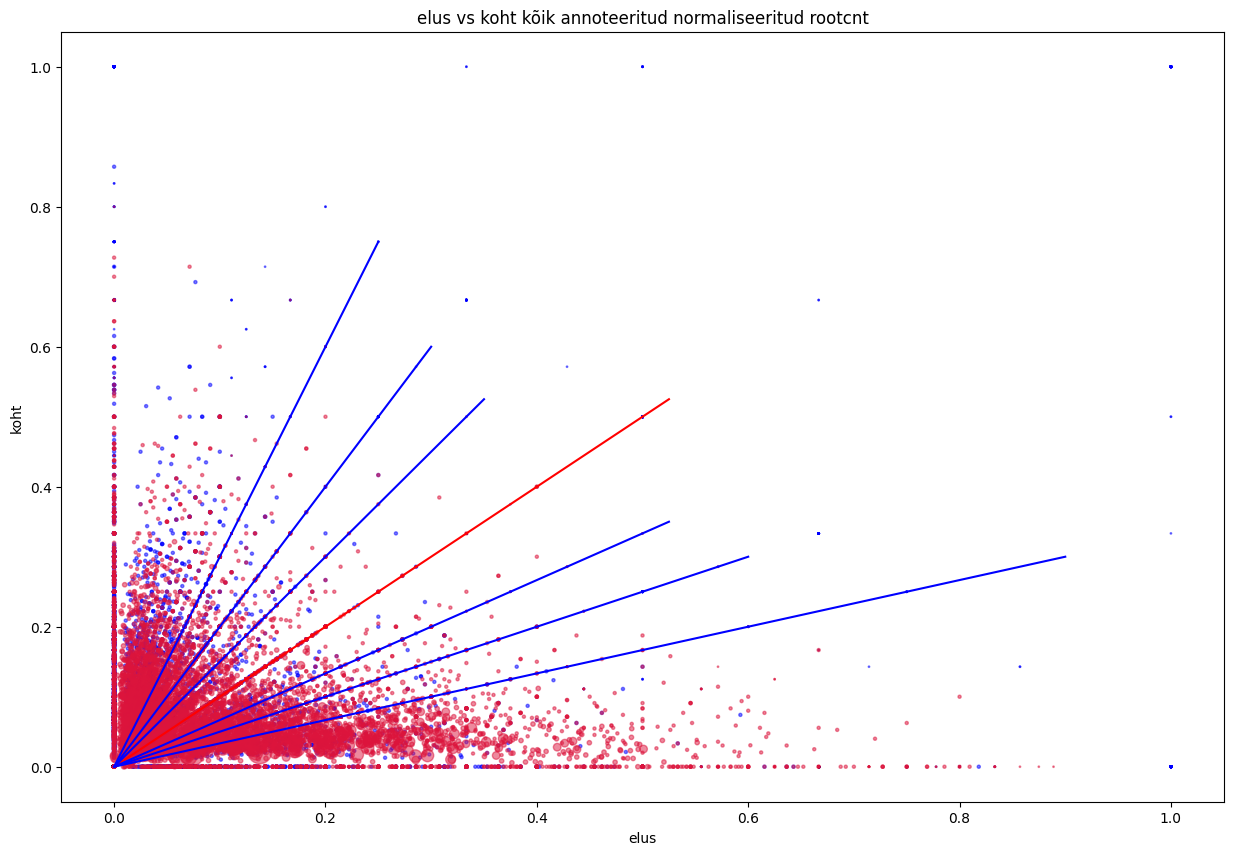

In [11]:
plt.figure(figsize=(15, 10))

# 45 kraadine joon: mitteinformatiivsed punktid
plt.plot([0, 0.35*1.5], [0, 0.35*1.5], c='red')


# kiir : koht kindlamad näited
#plt.plot([0, 0.05*1.2], [0, 0.25*1.2], c='green')
# kiir 1: koht 3:1
plt.plot([0, 0.1*2.5], [0, 0.3*2.5], c='blue')
# kiir 2: koht 2:1
plt.plot([0, 0.1*3], [0, 0.2*3], c='blue')
# kiir 3: koht 1.5:1
plt.plot([0, 0.1*3.5], [0, 0.15*3.5], c='blue')
# kiir 4: elus 3:1
plt.plot([0, 0.3*3], [0, 0.1*3], c='blue')
# kiir 5: elus 2:1
plt.plot([0, 0.2*3], [0, 0.1*3], c='blue')
# kiir 6: elus 1.5:1
plt.plot([0, 0.15*3.5], [0, 0.1*3.5], c='blue')


# kõik mitte annoteeritud punktid
x = elusad2
y = kohad2
#N = len(source3)
#colors = np.random.rand(N)
area = [areadict[cnt] for cnt in roots2]
plt.scatter(x, y, s=area, c='blue', alpha=0.5)



# kõik annoteeritud punktid
x = elusad
y = kohad
#N = len(source3)
#colors = np.random.rand(N)
area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.5)




plt.title("elus vs koht kõik annoteeritud normaliseeritud rootcnt")
plt.ylabel("koht")
plt.xlabel("elus")

#print("ROHELINE - üsna kindlalt \nKOLLANE - suure tõenäosusega \nORANŽ - maybe\nPUNANE - liiga küsitav")
#print("Kiired:\nPUNANE - 45\nÜLEJÄÄNUD - 3:1, 2:1 ja 1.5:1 jooned\nRoheline - kohtade puhul veel rangem piir")

plt.show()

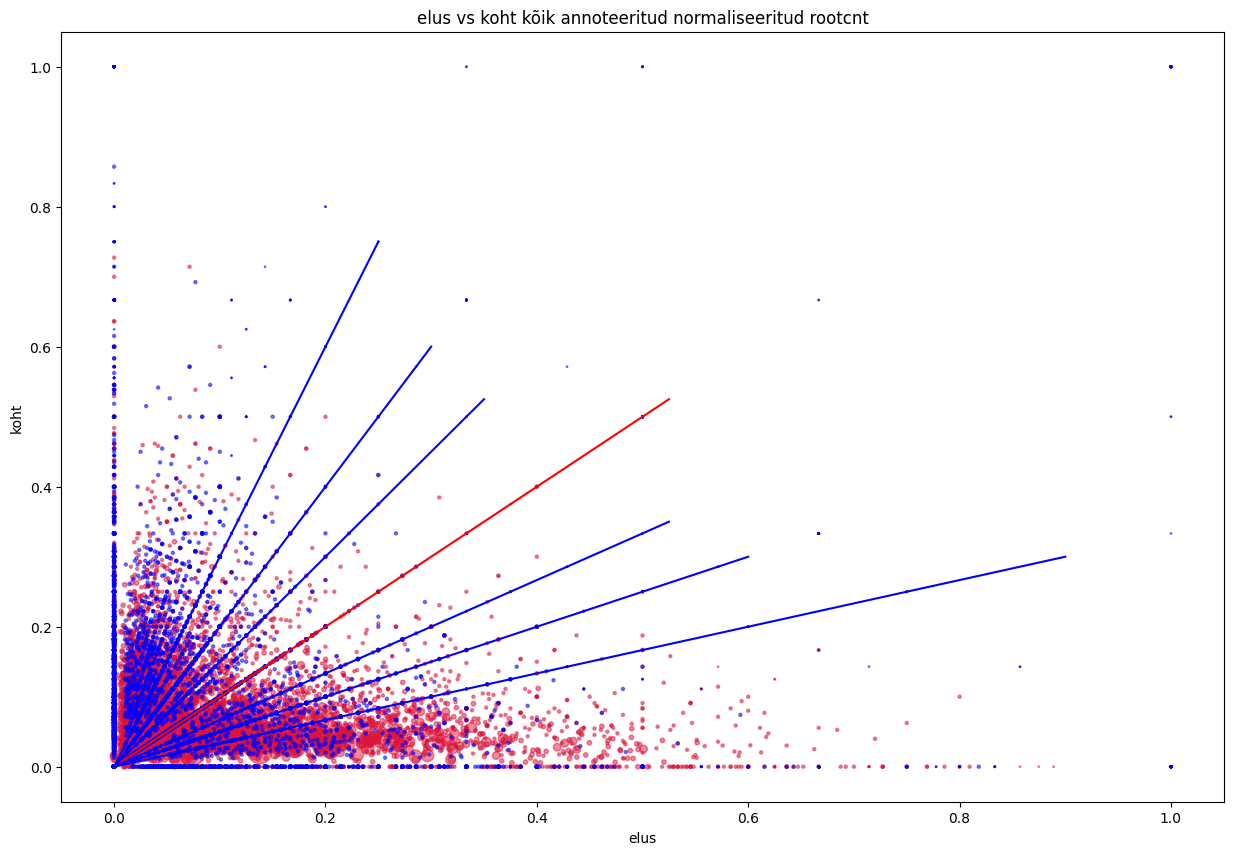

In [15]:
plt.figure(figsize=(15, 10))

# 45 kraadine joon: mitteinformatiivsed punktid
plt.plot([0, 0.35*1.5], [0, 0.35*1.5], c='red')


# kiir : koht kindlamad näited
#plt.plot([0, 0.05*1.2], [0, 0.25*1.2], c='green')
# kiir 1: koht 3:1
plt.plot([0, 0.1*2.5], [0, 0.3*2.5], c='blue')
# kiir 2: koht 2:1
plt.plot([0, 0.1*3], [0, 0.2*3], c='blue')
# kiir 3: koht 1.5:1
plt.plot([0, 0.1*3.5], [0, 0.15*3.5], c='blue')
# kiir 4: elus 3:1
plt.plot([0, 0.3*3], [0, 0.1*3], c='blue')
# kiir 5: elus 2:1
plt.plot([0, 0.2*3], [0, 0.1*3], c='blue')
# kiir 6: elus 1.5:1
plt.plot([0, 0.15*3.5], [0, 0.1*3.5], c='blue')

# kõik annoteeritud punktid
x = elusad
y = kohad
#N = len(source3)
#colors = np.random.rand(N)
area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.5)

# kõik mitte annoteeritud punktid
x = elusad2
y = kohad2
#N = len(source3)
#colors = np.random.rand(N)
area = [areadict[cnt] for cnt in roots2]
plt.scatter(x, y, s=area, c='blue', alpha=0.5)

plt.title("elus vs koht kõik annoteeritud normaliseeritud rootcnt")
plt.ylabel("koht")
plt.xlabel("elus")

#print("ROHELINE - üsna kindlalt \nKOLLANE - suure tõenäosusega \nORANŽ - maybe\nPUNANE - liiga küsitav")
#print("Kiired:\nPUNANE - 45\nÜLEJÄÄNUD - 3:1, 2:1 ja 1.5:1 jooned\nRoheline - kohtade puhul veel rangem piir")

plt.show()

In [16]:
con.close()